In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import mplfinance as mpf # k线图
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macos
# plt.rcParams['font.sans-serif'] = ['SimHei']  # windows
plt.rcParams['axes.unicode_minus'] = False

### 创建你的第一个量化策略
1. 参数设置：ticker 数据获取与标准化
2. 参数设置：captical, commission, benchmark
3. 策略与运行：indicators, signals
4. 策略与运行：cross-order, limit, pos, 涨跌停
5. 统计与验证：daily result (pnl)
6. 统计与验证：strategy statistics
7. 结果可视化：持仓收益、最大回撤、日盈亏
8. 结果可视化：市场基准（beta）对比

In [7]:
# 全局参数设置：工商银行为例
ticker = "601398.SS"
benchmark_ticker = "000001.SS"
start_date = "2024-12-31"
end_date = "2025-03-01"

#### 参数设置：ticker 数据获取与标准化
- 数据获取：yf.download(), 定义参数（股票代码、开始日期、结束日期、复权方式）
- 数据清洗：nan值 -> dropna
- 数据预览：整体看下数据

In [11]:
# 函数1：数据获取
def fetcher_data(ticker:str,start_date:str,end_date:str,auto_clean=True) -> pd.DataFrame:
    """ 获取数据 """
    try:
        print("正在获取历史数据：",ticker, start_date, end_date)
        data = yf.download(tickers=ticker,start=start_date,end=end_date,progress=False)
        # yfinance 个性化处理：去除第二行的列名，即ticker值
        data = data.droplevel(level=1,axis=1)
        print("完成数据获取，共有记录（条数）：", len(data))

        if auto_clean:
            clean_data(data)
    
        return data
    except Exception as e:
        print("获取数据异常：",e)
        return pd.DataFrame

# 函数2：数据清洗
def clean_data(data:pd.DataFrame) -> pd.DataFrame:
    """ 清洗数据：缺失值 """
    try:
        count_nan = data.isnull().sum().sum()
        print("当前data共有缺失值（个数）：",count_nan)
        data = data.dropna()
        count_nan = data.isnull().sum().sum()
        print("缺失值处理完毕，当前缺失值（个数）：",count_nan)
        return data
    except Exception as e:
        print("获取数据异常：",e)
        return data

# 函数3：数据预览
def preview_data(data:pd.DataFrame) -> pd.DataFrame:
    """ 按需要的格式预览数据 """
    print("数据预览：",data)

In [12]:
data = fetcher_data(ticker,start_date,end_date)
preview_data(data)

正在获取历史数据： 601398.SS 2024-12-31 2025-03-01
完成数据获取，共有记录（条数）： 37
当前data共有缺失值（个数）： 0
缺失值处理完毕，当前缺失值（个数）： 0
数据预览： Price          Close      High       Low      Open     Volume
Date                                                         
2024-12-31  6.633809  6.739259  6.614636  6.652981  520980174
2025-01-02  6.518771  6.691327  6.480425  6.624222  531482465
2025-01-03  6.432493  6.547530  6.346215  6.528357  521073986
2025-01-06  6.470839  6.499599  6.317456  6.432493  474224652
2025-01-07  6.552525  6.572114  6.425196  6.474169  382021777
2025-01-08  6.621087  6.699443  6.532936  6.552525  399684284
2025-01-09  6.572114  6.630881  6.523142  6.621087  236723419
2025-01-10  6.532936  6.601497  6.464374  6.581908  262025788
2025-01-13  6.464375  6.532936  6.356635  6.523142  330603282
2025-01-14  6.474169  6.513347  6.425197  6.454580  341885264
2025-01-15  6.493758  6.591703  6.444785  6.464374  307598274
2025-01-16  6.542730  6.552525  6.434991  6.503552  267468138
2025-01-17  6.474169  6.

#### 参数设置：capital, commission, slippage, benchmark
- initial_capital：初始资金，决定能买多少股票，是收益率、仓位计算的基准，回测设置为尽可能大的整数（如100万）
- commission: 交易手续费（佣金 + 税费），总共约为千1，即0.1% -> 0.001
- slippage: 滑点（成交价偏差），实际成交价与理论信号价的偏差，反应市场流动性和成交延迟，回测过程中设置为万5，即0.05% -> 0.0005
- benchmark: 市场基准（beta），使用上证指数 000001.SS

In [13]:
# 全局交易参数设置
trading_config = {
    "initial_capital":1000000,
    "commission":0.001,
    "slippage":0.0005
}

In [14]:
benchmark_data = fetcher_data(benchmark_ticker,start_date,end_date)
preview_data(benchmark_data)

正在获取历史数据： 000001.SS 2024-12-31 2025-03-01
完成数据获取，共有记录（条数）： 37
当前data共有缺失值（个数）： 0
缺失值处理完毕，当前缺失值（个数）： 0
数据预览： Price             Close         High          Low         Open  Volume
Date                                                                  
2024-12-31  3351.762939  3413.455078  3351.762939  3406.965088  502700
2025-01-02  3262.561035  3351.721924  3242.086914  3347.938965  561400
2025-01-03  3211.429932  3273.565918  3205.775879  3267.076904  517600
2025-01-06  3206.923096  3219.488037  3185.462891  3209.782959  431000
2025-01-07  3229.644043  3230.853027  3190.460938  3203.306885  409700
2025-01-08  3230.167969  3246.291016  3175.725098  3218.857910  472900
2025-01-09  3211.393066  3228.972900  3205.909912  3220.720947  382900
2025-01-10  3168.523926  3220.106934  3168.523926  3211.707031  403700
2025-01-13  3160.754883  3172.699951  3140.978027  3148.825928  372700
2025-01-14  3240.939941  3245.219971  3159.431885  3165.160889  469200
2025-01-15  3227.116943  3245.904053  32

In [21]:
# 函数4：对比投资标的与市场基准的价格曲线
def plot_compare_benchmark(ticker,benchmark_ticker,data,benchmark_data,auto_normalize=True):
    combined_data = pd.DataFrame({
        ticker: data['Close'],
        benchmark_ticker: benchmark_data['Close']
    })

    # 数据标准化（0~1）：解决价格差异太大导致无法直观对比的问题
    if auto_normalize:
        combined_data = combined_data / combined_data.iloc[0] * 100
        ylable = "相对涨幅（%）"
    else:
        ylable = "收盘价"

    combined_data.plot(figsize=(12,5), linewidth=2)
    plt.title(f"{ticker} vs {benchmark_ticker} 收盘价对比")
    plt.xlabel("日期")
    plt.ylabel(ylable)
    plt.grid(alpha=0.3)

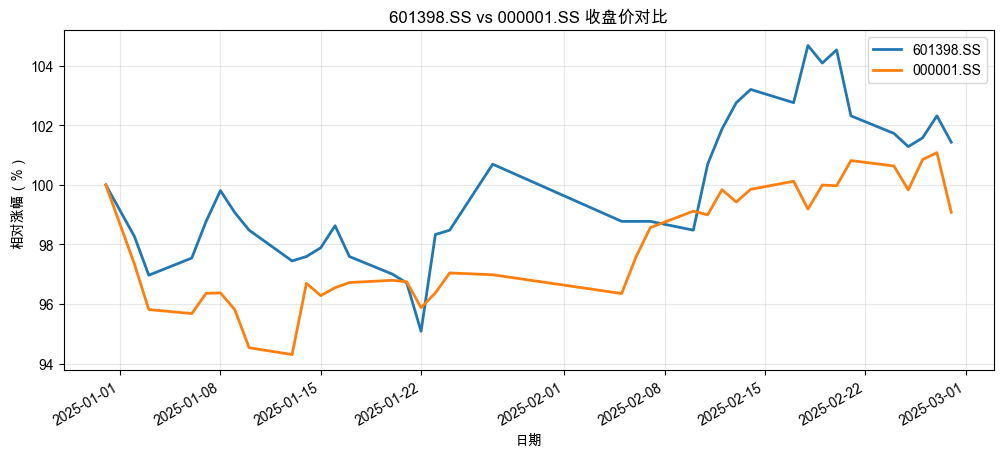

In [22]:
plot_compare_benchmark(ticker,benchmark_ticker,data,benchmark_data)